In [1]:
# ===========================
# SECTION 1: IMPORT LIBRARIES
# ===========================

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from tensorflow.keras.applications import EfficientNetV2S

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 50)
print("TensorFlow Version :", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU Detected :", gpus[0].name)
else:
    print("GPU Not Detected")

print("=" * 50)

2026-06-26 04:11:41.063080: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782447101.266408      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782447101.329065      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782447101.846783      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782447101.846820      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782447101.846823      58 computation_placer.cc:177] computation placer alr

TensorFlow Version : 2.19.0
GPU Detected : /physical_device:GPU:0


In [5]:
# ==========================================
# SECTION 2: DATASET CONFIGURATION
# ==========================================

TRAIN_DIR = "/kaggle/input/datasets/adithashok/odir10k/train"
VAL_DIR   = "/kaggle/input/datasets/adithashok/odir10k/val"
TEST_DIR  = "/kaggle/input/datasets/adithashok/odir10k/test"

IMG_SIZE = (384, 384)
BATCH_SIZE = 16
SEED = 42

print("Train Directory :", TRAIN_DIR)
print("Validation Directory :", VAL_DIR)
print("Test Directory :", TEST_DIR)

Train Directory : /kaggle/input/datasets/adithashok/odir10k/train
Validation Directory : /kaggle/input/datasets/adithashok/odir10k/val
Test Directory : /kaggle/input/datasets/adithashok/odir10k/test


In [6]:
# ==========================================
# SECTION 3: LOAD DATASETS
# ==========================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

print("\nClasses:")
print(class_names)

print("\nNumber of Classes:", len(class_names))

Found 8489 files belonging to 7 classes.


I0000 00:00:1782447369.317813      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782447369.323931      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1818 files belonging to 7 classes.
Found 1824 files belonging to 7 classes.

Classes:
['ageDegeneration', 'cataract', 'diabetes', 'glaucoma', 'hypertension', 'myopia', 'normal']

Number of Classes: 7


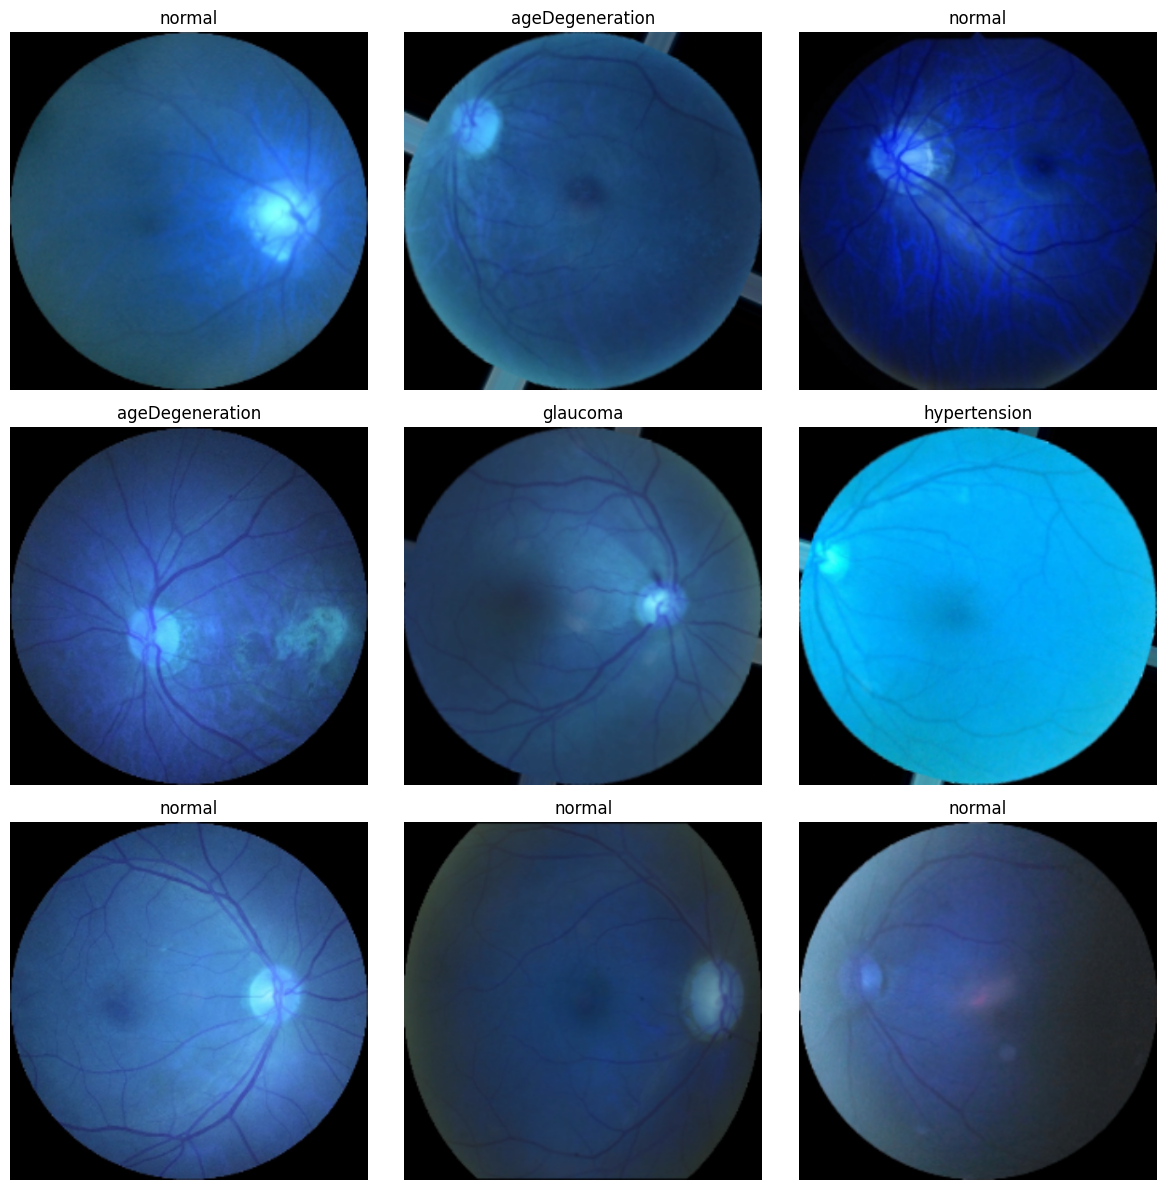

In [7]:
# ==========================================
# SECTION 4: VISUALIZE DATASET
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# Get one batch
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 12))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i].numpy().astype("uint8"))

    plt.title(class_names[np.argmax(labels[i])])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# ==========================================
# SECTION 5: DATASET OPTIMIZATION
# ==========================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("✅ Dataset optimization completed.")

✅ Dataset optimization completed.


In [9]:
# ==========================================
# SECTION 6: DATA AUGMENTATION
# ==========================================

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ],
    name="augmentation"
)

print("✅ Data Augmentation Ready")

✅ Data Augmentation Ready


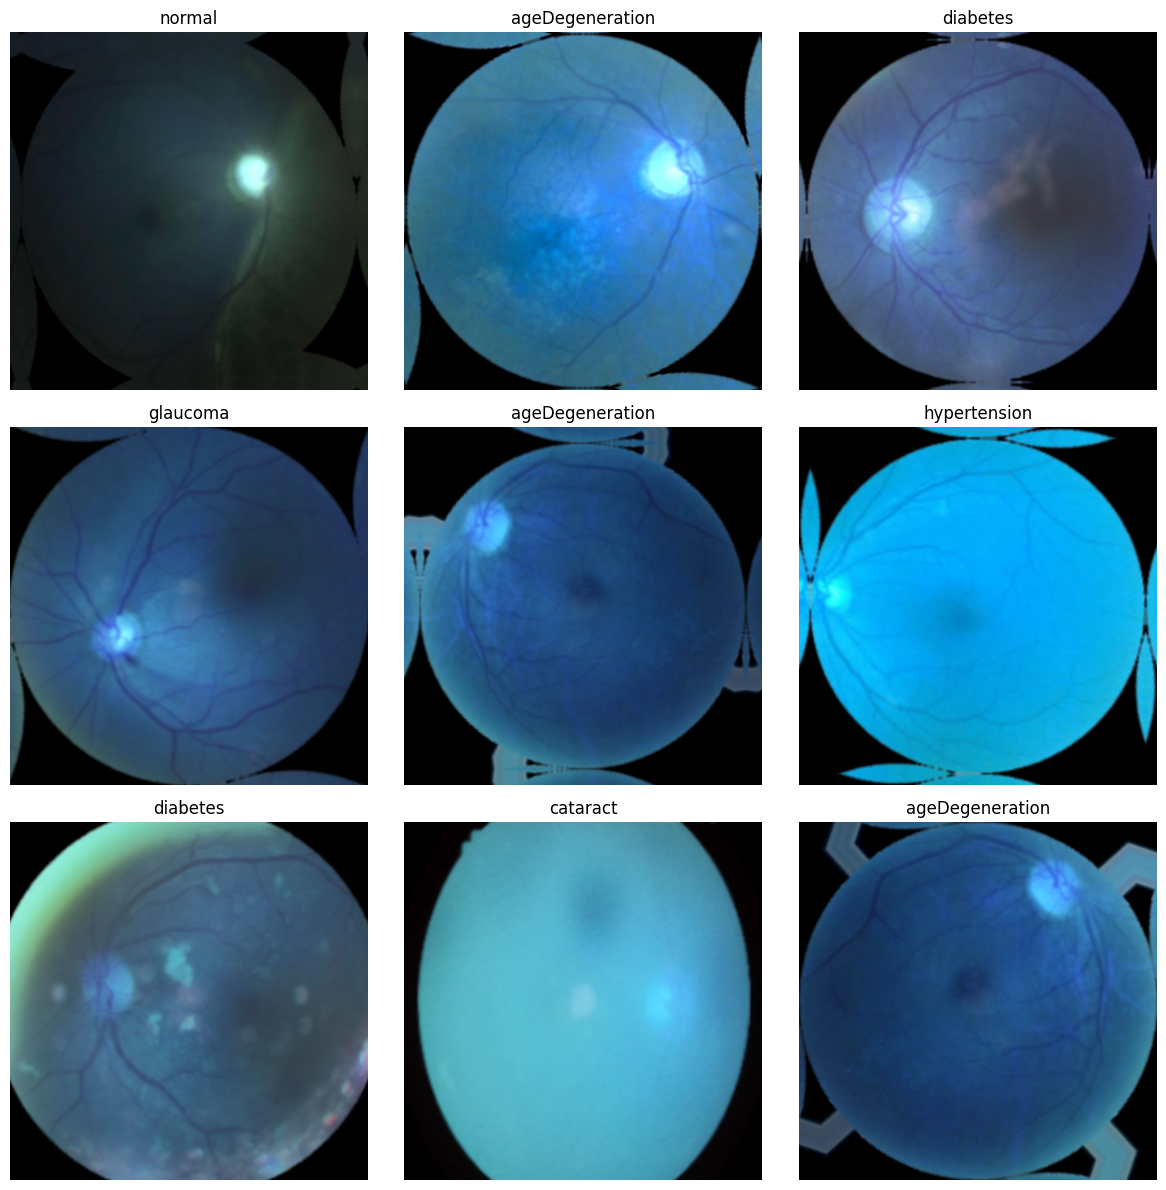

In [10]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12,12))

for i in range(9):

    augmented = data_augmentation(
        tf.expand_dims(images[i], axis=0),
        training=True
    )

    plt.subplot(3,3,i+1)

    plt.imshow(augmented[0].numpy().astype("uint8"))

    plt.title(class_names[np.argmax(labels[i])])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# ==========================================
# SECTION 7: BUILD EFFICIENTNETV2S MODEL
# ==========================================

base_model = EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=(384, 384, 3)
)

# Freeze the backbone for initial training
base_model.trainable = False

print("✅ EfficientNetV2S Loaded")
print("Trainable:", base_model.trainable)

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ EfficientNetV2S Loaded
Trainable: False


In [12]:
# ==========================================
# SECTION 7.1: BUILD CLASSIFICATION HEAD
# ==========================================

inputs = keras.Input(shape=(384, 384, 3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(
    512,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.0001)
)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = keras.Model(inputs, outputs)

print("✅ Model Created")

✅ Model Created


In [13]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 12, 12, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,997,991 (80.10 MB)

 Trainable params: 663,047 (2.53 MB)

 Non-trainable params: 20,334,944 (77.57 MB)

In [14]:
# ==========================================
# SECTION 8: COMPILE MODEL
# ==========================================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3
)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("✅ Model Compiled Successfully")

✅ Model Compiled Successfully


In [16]:
# ==========================================
# SECTION 9: CALLBACKS
# ==========================================

callbacks = [

    ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print("✅ Callbacks Ready")

✅ Callbacks Ready


In [17]:
class_weights = {
    0: 1.0,   # ageDegeneration
    1: 1.0,   # cataract
    2: 1.8,   # diabetes (higher priority)
    3: 1.0,   # glaucoma
    4: 1.0,   # hypertension
    5: 1.0,   # myopia
    6: 0.8    # normal (slightly lower)
}

print(class_weights)

{0: 1.0, 1: 1.0, 2: 1.8, 3: 1.0, 4: 1.0, 5: 1.0, 6: 0.8}


In [18]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/20


E0000 00:00:1782448000.744214      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetv2-s_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1782448003.204258     158 cuda_dnn.cc:529] Loaded cuDNN version 91002


531/531 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.6870 - loss: 1.1582 - precision: 0.7233 - recall: 0.6561
Epoch 1: val_accuracy improved from None to 0.78988, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
531/531 ━━━━━━━━━━━━━━━━━━━━ 173s 279ms/step - accuracy: 0.7252 - loss: 0.9520 - precision: 0.7613 - recall: 0.6936 - val_accuracy: 0.7899 - val_loss: 0.5880 - val_precision: 0.8119 - val_recall: 0.7552 - learning_rate: 0.0010
Epoch 2/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.7663 - loss: 0.7358 - precision: 0.8063 - recall: 0.7261
Epoch 2: val_accuracy improved from 0.78988 to 0.83883, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
531/531 ━━━━━━━━━━━━━━━━━━━━ 142s 267ms/step - accuracy: 0.7605 - loss: 0.7438 - precision: 0.8015 - recall: 0.7189 - val_accuracy: 0.8388 - val_loss: 0.5165 - val_precision: 0.8620 - val_recall: 0.8146 - learning_rate: 0.0010
Epoch 3/20
531/531 ━━━━━━━━━

In [19]:
from sklearn.metrics import classification_report
import numpy as np

# Evaluate
loss, accuracy, precision, recall = model.evaluate(test_ds, verbose=1)

print(f"Test Loss      : {loss:.4f}")
print(f"Test Accuracy  : {accuracy*100:.2f}%")
print(f"Precision      : {precision*100:.2f}%")
print(f"Recall         : {recall*100:.2f}%")

# Predictions
pred = model.predict(test_ds, verbose=0)
pred = np.argmax(pred, axis=1)

true = []
for _, labels in test_ds:
    true.extend(np.argmax(labels.numpy(), axis=1))

print(classification_report(
    true,
    pred,
    target_names=class_names
))

114/114 ━━━━━━━━━━━━━━━━━━━━ 22s 196ms/step - accuracy: 0.8410 - loss: 0.4731 - precision: 0.8726 - recall: 0.8147
Test Loss      : 0.4731
Test Accuracy  : 84.10%
Precision      : 87.26%
Recall         : 81.47%
                 precision    recall  f1-score   support

ageDegeneration       0.96      0.88      0.92       219
       cataract       0.96      0.96      0.96       225
       diabetes       0.57      0.67      0.62       242
       glaucoma       0.95      0.86      0.90       270
   hypertension       1.00      0.93      0.96       225
         myopia       0.99      0.98      0.99       211
         normal       0.70      0.72      0.71       432

       accuracy                           0.84      1824
      macro avg       0.87      0.86      0.87      1824
   weighted avg       0.85      0.84      0.85      1824



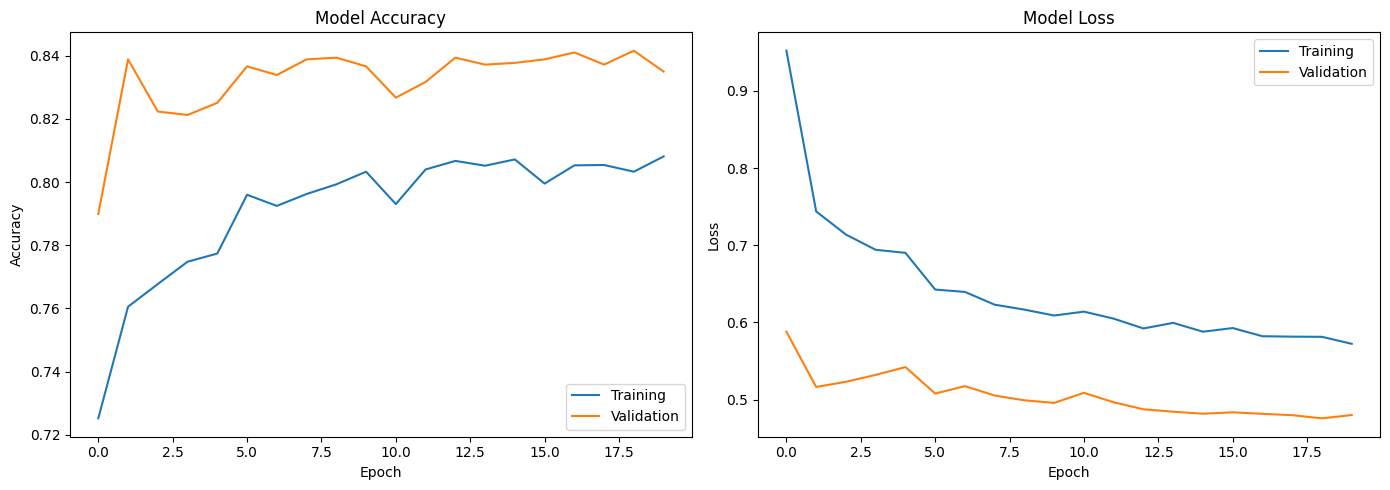

In [22]:
# ==========================================
# SECTION 11: TRAINING HISTORY
# ==========================================

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
plt.savefig("/kaggle/working/training_history.png", dpi=300)

<Figure size 640x480 with 0 Axes>

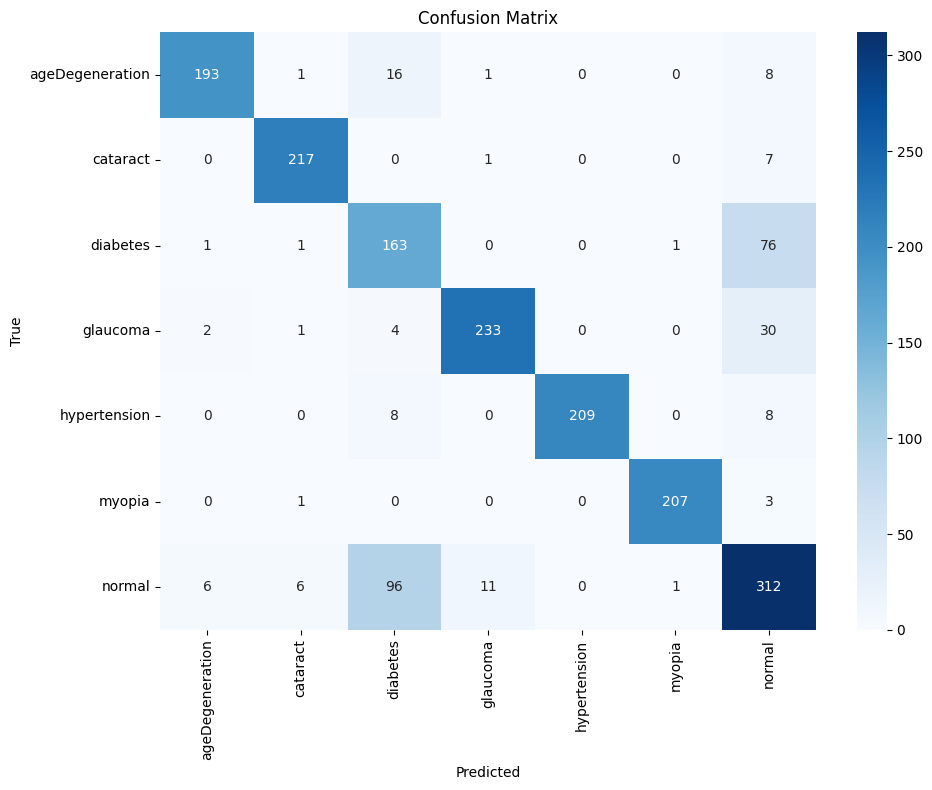

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

pred = model.predict(test_ds, verbose=0)
pred = np.argmax(pred, axis=1)

true = []

for _, labels in test_ds:
    true.extend(np.argmax(labels.numpy(), axis=1))

cm = confusion_matrix(true, pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig("/kaggle/working/confusion_matrix.png", dpi=300)

plt.show()

In [25]:
results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall"
    ],
    "Value":[
        accuracy,
        precision,
        recall
    ]
})

results

,Metric,Value
0,Accuracy,0.841009
1,Precision,0.872578
2,Recall,0.814693


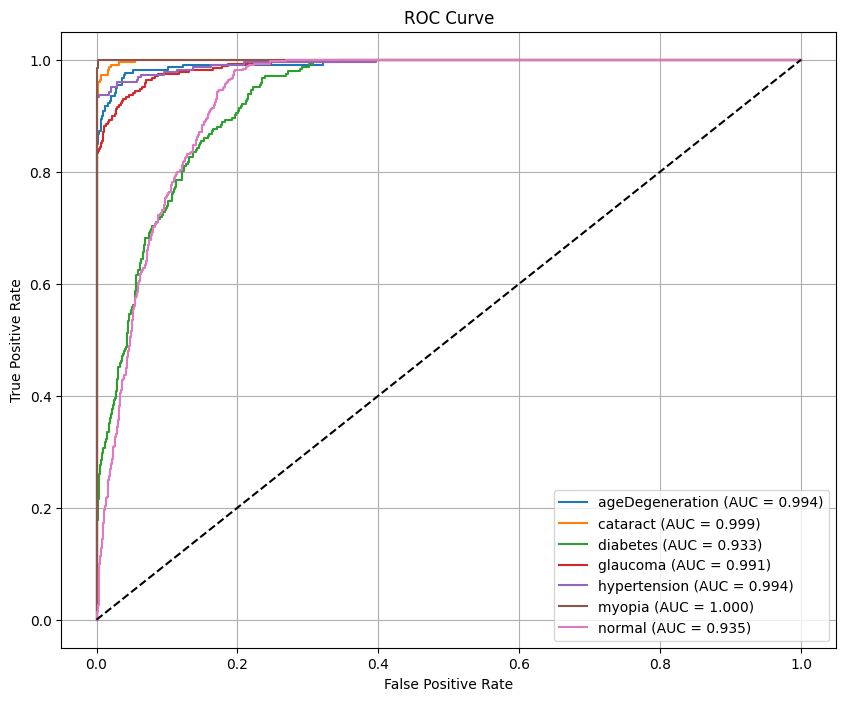

In [26]:
# ==========================================
# SECTION 14: ROC CURVES
# ==========================================

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# True labels
y_true = []

for _, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)

# Prediction probabilities
y_pred_prob = model.predict(test_ds, verbose=0)

# Binarize labels
y_true_bin = label_binarize(
    y_true,
    classes=np.arange(len(class_names))
)

plt.figure(figsize=(10,8))

for i in range(len(class_names)):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_pred_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC = {roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.grid(True)

plt.savefig(
    "/kaggle/working/roc_curve.png",
    dpi=300
)

plt.show()

In [27]:
# ==========================================
# SECTION 15: MODEL SUMMARY
# ==========================================

with open("/kaggle/working/model_summary.txt","w") as f:

    model.summary(
        print_fn=lambda x: f.write(x + "\n")
    )

print("✅ Model summary saved.")

✅ Model summary saved.


In [28]:
print("="*60)
print("ODIR10K RETINAL DISEASE CLASSIFICATION")
print("="*60)

print(f"Model        : EfficientNetV2S")
print(f"Input Size   : {IMG_SIZE}")
print(f"Classes      : {len(class_names)}")

print()

print(f"Test Accuracy : {accuracy*100:.2f}%")
print(f"Precision     : {precision*100:.2f}%")
print(f"Recall        : {recall*100:.2f}%")

print("="*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*60)

ODIR10K RETINAL DISEASE CLASSIFICATION
Model        : EfficientNetV2S
Input Size   : (384, 384)
Classes      : 7

Test Accuracy : 84.10%
Precision     : 87.26%
Recall        : 81.47%
PROJECT COMPLETED SUCCESSFULLY
